### Xây dựng và huấn luyện mô hình LSTM

#### Chuẩn bị dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('Data/data_preprocessing.csv', index_col='Date', parse_dates=True)
df.head()

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1985-01-01,0.0,24.12,66.46,26.87
1985-01-02,0.0,24.27,66.08,26.60
1985-01-03,0.1,25.02,61.42,22.44
1985-01-04,0.2,25.26,60.54,22.89
1985-01-05,0.0,25.05,59.92,24.88


In [3]:
# Sắp xếp và kiểm tra dữ liệu
df = df.sort_index()

# kiểm tra liên tục thời gian
print(df.index.to_series().diff().value_counts().head())

Date
1 days    12204
Name: count, dtype: int64


In [4]:
# Chọn biến đầu vào & mục tiêu
features = ['Precipitation', 'Relative Humidity', 'Wind Speed']
target = 'Temperature'

X = df[features]
y = df[target]

In [5]:
# Chia tập dữ liệu: 70% train, 15% validation, 15% test
total_samples = len(X)
train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

In [6]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8543, 3)
y_train shape: (8543,)
X_val shape: (1830, 3)
y_val shape: (1830,)
X_test shape: (1832, 3)
y_test shape: (1832,)


In [7]:
# Chuẩn hóa dữ liệu
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1))

In [8]:
# Hàm tạo chuỗi dữ liệu > Dự đoán ngày tiếp theo
def create_sequences(X, y, time_step):
    X_seq, y_seq = [], []
    
    for i in range(len(X) - time_step):
        X_seq.append(X[i:i + time_step])
        y_seq.append(y[i + time_step])
        
    return np.array(X_seq), np.array(y_seq)

In [9]:
# Xác định time_step = 30 
time_step = 30

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_step)
X_val_seq, y_val_seq     = create_sequences(X_val_scaled, y_val_scaled, time_step)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_scaled, time_step)

#### Xây dựng mô hình

In [10]:
# Khai báo thư viện
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [11]:
print("Train shape:", X_train_seq.shape)
print("Test shape :", X_test_seq.shape)

Train shape: (8513, 30, 3)
Test shape : (1802, 30, 3)


In [12]:
# Xây dựng mô hình LSTM
model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(units=50, return_sequences=True),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

In [13]:
# Biên dịch mô hình
model.compile(optimizer='adam', loss='mean_squared_error')

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 50)              │          10,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,051 (121.29 KB)

 Trainable params: 31,051 (121.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Thiết lập callbacks
# checkpoint = ModelCheckpoint('best_lstm_temp_model.h5', save_best_only=True, monitor='val_loss', mode='min')
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [16]:
# Huấn luyện mô hình với epochs=50, batch_size=32
history = model.fit(X_train_seq, y_train_seq,
                               epochs=50, 
                               batch_size=32, 
                               validation_data=(X_val_seq, y_val_seq),
                               # callbacks=[checkpoint, early_stop],
                               verbose=1)

Epoch 1/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0256 - val_loss: 0.0093
Epoch 2/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0132 - val_loss: 0.0088
Epoch 3/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0126 - val_loss: 0.0074
Epoch 4/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0120 - val_loss: 0.0100
Epoch 5/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0113 - val_loss: 0.0150
Epoch 6/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0111 - val_loss: 0.0085
Epoch 7/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0108 - val_loss: 0.0067
Epoch 8/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0104 - val_loss: 0.0068
Epoch 9/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0099 - val_loss: 0.0076
Epoch 10/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0100 - val_loss: 0.0123
Epoch 11/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0097 - val_loss: 0.0112
Epoch 12/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 

In [17]:
# Dự đoán trên tập kiểm tra
y_pred_scaled = model.predict(X_test_seq)

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step   


In [18]:
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test_seq)

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

MSE : 1.2890580752486298
RMSE: 1.135366934188516
MAE : 0.8815770227768841
R2  : 0.517123779719789


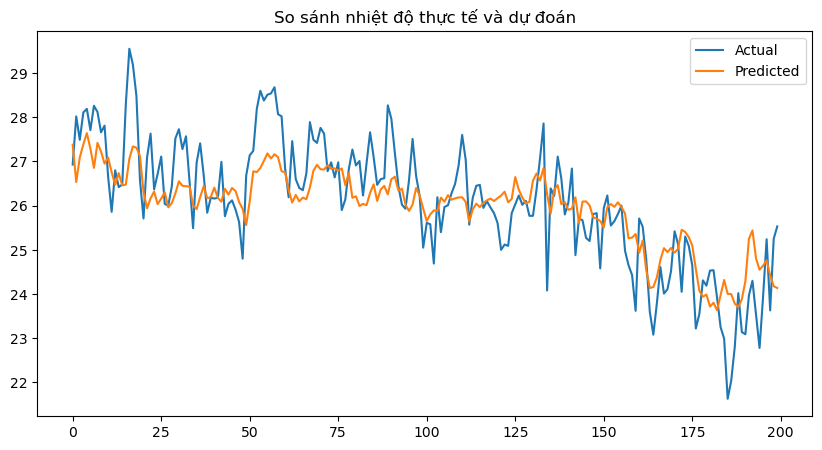

In [20]:
 # Vẽ biểu đồ so sánh Thực tế vs Dự đoán
plt.figure(figsize=(10,5))
plt.plot(y_test_original[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.title("So sánh nhiệt độ thực tế và dự đoán")
plt.show()

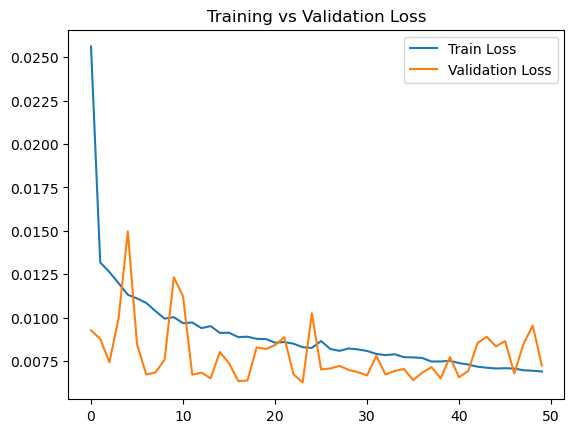

In [21]:
# Vẽ biểu đồ Loss trong quá trình train
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [22]:
print("===== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH =====")
print(f"Sai số bình phương trung bình (MSE): {mse:.4f}")
print(f"Căn bậc hai sai số (RMSE): {rmse:.4f} °C")
print(f"Sai số tuyệt đối trung bình (MAE): {mae:.4f} °C")
print(f"Hệ số xác định (R²): {r2:.4f}")

===== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH =====
Sai số bình phương trung bình (MSE): 1.2891
Căn bậc hai sai số (RMSE): 1.1354 °C
Sai số tuyệt đối trung bình (MAE): 0.8816 °C
Hệ số xác định (R²): 0.5171


In [23]:
comparison_df = pd.DataFrame({
    "Nhiệt độ thực tế (°C)": y_test_original.flatten(),
    "Nhiệt độ dự đoán (°C)": y_pred.flatten()
})

comparison_df["Sai số"] = comparison_df["Nhiệt độ thực tế (°C)"] - comparison_df["Nhiệt độ dự đoán (°C)"]
comparison_df["Sai số tuyệt đối"] = comparison_df["Sai số"].abs()

print("===== BẢNG SO SÁNH GIÁ TRỊ THỰC TẾ VÀ DỰ ĐOÁN =====")
display(comparison_df.round(2).head(10))

===== BẢNG SO SÁNH GIÁ TRỊ THỰC TẾ VÀ DỰ ĐOÁN =====


,Nhiệt độ thực tế (°C),Nhiệt độ dự đoán (°C),Sai số,Sai số tuyệt đối
0,26.93,27.379999,-0.45,0.45
1,28.02,26.530001,1.49,1.49
2,27.49,27.090000,0.40,0.40
3,28.11,27.389999,0.72,0.72
4,28.19,27.639999,0.55,0.55
5,27.71,27.290001,0.42,0.42
6,28.26,26.860001,1.40,1.40
7,28.12,27.420000,0.70,0.70
8,27.66,27.230000,0.43,0.43
9,27.81,26.950001,0.86,0.86


In [24]:
# Lấy index tương ứng với tập test gốc
test_index = df.index[-len(y_test_seq):]

comparison_df = pd.DataFrame({
    "Ngày": test_index,
    "Nhiệt độ thực tế (°C)": y_test_original.flatten(),
    "Nhiệt độ dự đoán (°C)": y_pred.flatten()
})

comparison_df.set_index("Ngày", inplace=True)
comparison_df.head(20)

print("===== SO SÁNH THEO TỪNG NGÀY =====")
display(comparison_df.round(2).head(20))

===== SO SÁNH THEO TỪNG NGÀY =====


,Nhiệt độ thực tế (°C),Nhiệt độ dự đoán (°C)
Ngày,,
2013-06-26,26.93,27.379999
2013-06-27,28.02,26.530001
2013-06-28,27.49,27.090000
2013-06-29,28.11,27.389999
2013-06-30,28.19,27.639999
2013-07-01,27.71,27.290001
2013-07-02,28.26,26.860001
2013-07-03,28.12,27.420000
2013-07-04,27.66,27.230000


In [25]:
mape = np.mean(np.abs((y_test_original - y_pred) / y_test_original)) * 100
print(f"Sai số phần trăm trung bình (MAPE): {mape:.2f}%")

Sai số phần trăm trung bình (MAPE): 3.35%


In [26]:
model.save("model_lstm.keras")